In [1]:
import pandas as pd
import numpy as np
import json
import cvxpy as cp
import matplotlib.pyplot as plt

In [21]:
columns = []
for i in range(1,6):
    columns.append(f'Building {i}')

In [22]:
time = np.arange(0,24,1)

In [23]:
priceSwitch = [(13,15,19,24), (10, 19, 28, 10)]
priceDaily = []
for i in range(0,len(time)):
    for j in range(0,len(time)//24):
        for k in range(0,len(priceSwitch[0])):
            if i < priceSwitch[0][k]:
                priceDaily.append(priceSwitch[1][k])
                break

In [24]:
flexUsage = np.zeros(len(columns))
usageTime = np.zeros(len(columns))

Testing of community optim

In [25]:
from community_optim import *

ModuleNotFoundError: No module named 'communityController'

In [ ]:
with open('transInfo.json') as fp:
    transInfo = json.load(fp)

In [ ]:
controlAliasList = ["2", "3", "4", "5", "9", "10", "12", "15", "17", "22", "24", "25", "26", "27", "28"]

In [ ]:
with open('../../configs/indexMapping.json') as fp:
    sensorIdxMapping = json.load(fp)        # Map sensor indices to simulation indices
simIdxMapping = {v: k for k, v in sensorIdxMapping.items()}     # Map simulation indices to sensor indices
aliasesSensorIdx = [simIdxMapping[alias] for alias in controlAliasList]       # Convert list of controlled buildings from sim idx to sensor idx

In [ ]:
n = 10
numBuildings = len(controlAliasList)
# coordinator = Coordinator(len(controlAliasList), n, 1)
coordinator = Coordinator(2, n, 1)

Is DPP? True
Is DCP? True


In [ ]:
coordinator.AdjustInit(verbose=True)

(CVXPY) Feb 18 09:41:48 PM: Your problem has 20 variables, 70 constraints, and 112 parameters.
(CVXPY) Feb 18 09:41:48 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 18 09:41:48 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 18 09:41:48 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Feb 18 09:41:48 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) Feb 18 09:41:48 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Feb 18 09:41:48 PM: Applying reduction Dcp2Cone
(CVXPY) Feb 18 09:41:48 PM: Applying reduction CvxAttr2Constr
(CVXPY) Feb 18 09:41:48 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Feb 18 09:41:48 PM: Applying reduction CLARABEL
(CVXPY) Feb 18 09:41:48 PM: Finished problem compilation (took 2.669e-02 seconds).
(CVXPY) Feb 18 09:41:48 PM: (Subsequent compilations of this problem, using the same arguments, shou

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 30
  constraints 

(CVXPY) Feb 18 09:41:48 PM: Problem status: optimal
(CVXPY) Feb 18 09:41:48 PM: Optimal value: 1.298e-09
(CVXPY) Feb 18 09:41:48 PM: Compilation took 2.669e-02 seconds
(CVXPY) Feb 18 09:41:48 PM: Solver (including time spent in interface) took 2.924e-03 seconds


  0  +1.0178e+04  -4.0107e+04  4.94e+00  3.06e-01  1.65e+00  1.00e+00  7.83e+03   ------   
  1  +8.9913e+01  -2.6796e+04  2.99e+02  1.87e-02  7.77e-02  7.11e-01  2.88e+02  9.74e-01  
  2  +9.8603e+00  -1.5472e+03  1.58e+02  1.08e-03  1.00e-01  4.41e+01  4.48e+01  9.57e-01  
  3  +7.6507e+00  -4.1262e+01  6.39e+00  3.37e-05  5.41e-02  1.20e+00  1.49e+00  9.67e-01  
  4  +1.2861e+00  -7.3898e+00  6.75e+00  2.34e-06  8.85e-03  1.13e-01  2.38e-01  9.90e-01  
  5  +2.5058e-01  -6.5499e-01  9.06e-01  2.95e-08  2.89e-04  7.78e-03  2.22e-02  9.90e-01  
  6  +4.8728e-02  -1.1733e-01  1.66e-01  3.47e-10  4.34e-06  1.29e-03  3.06e-03  9.90e-01  
  7  +9.6684e-03  -2.2029e-02  3.17e-02  4.07e-12  5.07e-08  2.32e-04  4.28e-04  9.90e-01  
  8  +1.9447e-03  -4.2688e-03  6.21e-03  4.85e-14  5.96e-10  4.36e-05  6.06e-05  9.90e-01  
  9  +3.9483e-04  -8.4477e-04  1.24e-03  7.12e-16  7.01e-12  8.43e-06  8.65e-06  9.90e-01  
 10  +8.0682e-05  -1.6955e-04  2.50e-04  1.47e-16  7.64e-14  1.66e-06  1.24e-06 

In [ ]:
params = coordinator.adjustProb.prob.param_dict
vars = coordinator.adjustProb.prob.var_dict

In [ ]:
for key, value in params.items():
    print(key, value.value.shape, value.value.sum())

usagePenalty (2,) 0.2
predLoad (2, 10) 20.0
flexMax (2, 10) 4000.0
flexMin (2, 10) 0.0
baseLoad (2, 10) 20.0
pow_ref (10,) 40.0
trans_ref (2, 10) 40.0


In [ ]:
for key, value in vars.items():
    print(key, value.value.shape, value.value.sum())

flexLoad (2, 10) -0.00015797101411384206


In [ ]:
vars['flexLoad'].value

array([[-7.89855071e-06, -7.89855071e-06, -7.89855071e-06,
        -7.89855071e-06, -7.89855071e-06, -7.89855071e-06,
        -7.89855071e-06, -7.89855071e-06, -7.89855071e-06,
        -7.89855071e-06],
       [-7.89855071e-06, -7.89855071e-06, -7.89855071e-06,
        -7.89855071e-06, -7.89855071e-06, -7.89855071e-06,
        -7.89855071e-06, -7.89855071e-06, -7.89855071e-06,
        -7.89855071e-06]])

In [ ]:
flex = vars['flexLoad'].value
# flex = np.zeros((2, n))

In [ ]:
print(2*(params['usagePenalty'].value@flex)**2@np.ones(n))
print(1*np.max(flex, axis=0)@np.ones(n))
print(3*np.ones(2)@np.power(flex, 2)@np.ones(n))

0.005410318561530746
-0.8223684212026526
0.4057738921148058


In [ ]:
coordinator.TransformerOverload()
coordinator.overloadList

True


[array([-50., -50., -50., -50., -50., -50., -50., -50., -50., -50., -50.,
        -50., -50., -50., -50., -50., -50., -50., -50., -50., -50., -50.,
        -50., -50., -50., -50., -50., -50., -50., -50., -50., -50., -50.,
        -50., -50., -50., -50., -50., -50., -50., -50., -50., -50., -50.,
        -50., -50., -50., -50., -50., -50., -50., -50., -50., -50., -50.,
        -50., -50., -50., -50., -50.]),
 array([-100., -100., -100., -100., -100., -100., -100., -100., -100.,
        -100., -100., -100., -100., -100., -100., -100., -100., -100.,
        -100., -100., -100., -100., -100., -100., -100., -100., -100.,
        -100., -100., -100., -100., -100., -100., -100., -100., -100.,
        -100., -100., -100., -100., -100., -100., -100., -100., -100.,
        -100., -100., -100., -100., -100., -100., -100., -100., -100.,
        -100., -100., -100., -100., -100., -100.])]

In [ ]:
coordinator.predictedLoad = predictedLoad
coordinator.predictedFlexibility = predictedFlex
coordinator.baseLoad = np.ones(coordinator.nsteps) * 10
overload = coordinator.TransformerOverload()
adjustValues = coordinator.Adjust(verbose=True)
coordinator.Dispatch(adjustValues)

In [ ]:
flexLoad = cp.Variable((5,2), name='flexLoad')
objective = cp.Minimize(cp.sum_squares(flexLoad))
constraints = [flexLoad <= np.ones((5,2)) * 5,
               flexLoad >= np.ones((5,2))*2]

prob = cp.Problem(objective, constraints)
prob.solve()

40.000000000000014

Building optim

In [ ]:
nsteps_eff = 60
nsteps = nsteps_eff
RC = 400
alpha = 0.08
step_mins = 1

In [ ]:
u_hvac = cp.Variable((nsteps_eff,1), integer=True, name='u_hvac')
u_bat = cp.Variable((nsteps_eff,1), name='u_bat')
u_tot = cp.Variable((nsteps_eff,1), name='u_tot')
y = cp.Variable((nsteps_eff,1), name='y')
stored = cp.Variable((nsteps_eff,1), name='stored')

y0 = cp.Parameter((1), name='y0')
ymin = cp.Parameter((nsteps_eff,1), name='y_min')
ymax = cp.Parameter((nsteps_eff,1), name='y_max')
d = cp.Parameter((nsteps_eff,1), name='d')
stored0 = cp.Parameter((1), name='stored0')
batmin = cp.Parameter((nsteps_eff,1), name='bat_min')
batmax = cp.Parameter((nsteps_eff,1), name='bat_max')
cost = cp.Parameter((nsteps_eff,1), name='cost')
power_ref = cp.Parameter((nsteps_eff,1), name='power_ref')

objective = cp.Minimize(1.0*cost.T@u_tot+10*cp.norm(y-ymax))

constraints = [u_hvac >= -1, u_hvac <=0,
                y[1:] >= ymin[1:],
                # y[1:] <= ymax[1:],
                y[0] == y0,
                u_tot == u_hvac * -6 + u_bat,
                u_bat <= 9.6, u_bat >= u_hvac * 6,
                stored[0] == stored0,
                stored >= batmin, stored <= batmax,
                u_tot <= power_ref
            ]
for i in range(1, nsteps_eff):
    constraints.append(y[i] == (-1/(RC)*y[i-1] + 1/(RC)*d[i-1] + alpha*u_hvac[i-1]*6)*step_mins + y[i-1])
    constraints.append(stored[i] == stored[i-1] + u_bat[i] * step_mins / 60)

prob = cp.Problem(objective, constraints)

In [ ]:
u_heat = cp.Variable((nsteps_eff,1), boolean=True, name='u_heat')
u_cool = cp.Variable((nsteps_eff,1), boolean=True, name='u_cool')
u_bat = cp.Variable((nsteps_eff,1), name='u_bat')
u_tot = cp.Variable((nsteps_eff,1), name='u_tot')
y = cp.Variable((nsteps_eff,1), name='y')
stored = cp.Variable((nsteps_eff,1), name='stored')

y0 = cp.Parameter((1), name='y0')
ymin = cp.Parameter((nsteps_eff,1), name='y_min')
ymax = cp.Parameter((nsteps_eff,1), name='y_max')
d = cp.Parameter((nsteps_eff,1), name='d')
stored0 = cp.Parameter((1), name='stored0')
batmin = cp.Parameter((nsteps_eff,1), name='bat_min')
batmax = cp.Parameter((nsteps_eff,1), name='bat_max')
cost = cp.Parameter((nsteps_eff,1), name='cost')
power_ref = cp.Parameter((nsteps_eff,1), name='power_ref')

objective = cp.Minimize(1.0*cost.T@u_tot+10*cp.norm(y-ymax)+10*cp.norm(y-ymin))

constraints = [
                u_heat + u_cool <= 1,
                y[0] == y0,
                u_tot == (u_cool + u_heat) * 6 + u_bat,
                u_bat <= 9.6, u_bat >= (u_cool + u_heat) * -6,
                stored[0] == stored0,
                stored >= batmin, stored <= batmax,
                u_tot <= power_ref
            ]
for i in range(1, nsteps_eff):
    constraints.append(y[i] == (-1/(RC)*y[i-1] + 1/(RC)*d[i-1] + alpha*(-6 * u_cool[i-1] + 6 * u_heat[i-1]))*step_mins + y[i-1])
    constraints.append(stored[i] == stored[i-1] + u_bat[i-1] * step_mins / 60)

prob = cp.Problem(objective, constraints)

In [ ]:
prob.is_dcp()

True

In [ ]:
horizonData = {
    'y0': np.array([18]),
    'y_min': np.ones((nsteps,1))*21,
    'y_max': np.ones((nsteps,1))*23,
    'd': np.ones((nsteps,1))*35,
    'stored0': np.array([10]),
    'bat_min': np.ones((nsteps,1))*1.5,
    'bat_max': np.ones((nsteps,1))*15,
    'cost': np.ones((nsteps,1)),
    'power_ref': np.ones((nsteps,1))*7
}

for key, param in prob.param_dict.items():
    param.value = horizonData[key]

prob.solve(verbose=True, solver='gurobi')

(CVXPY) Apr 16 07:13:39 PM: Your problem has 360 variables, 540 constraints, and 422 parameters.
(CVXPY) Apr 16 07:13:39 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 16 07:13:39 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 16 07:13:39 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 16 07:13:39 PM: Compiling problem (target solver=GUROBI).
(CVXPY) Apr 16 07:13:39 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> GUROBI
(CVXPY) Apr 16 07:13:39 PM: Applying reduction Dcp2Cone
(CVXPY) Apr 16 07:13:39 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 16 07:13:39 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 16 07:13:39 PM: Applying reduction GUROBI
(CVXPY) Apr 16 07:13:39 PM: Finished problem compilation (took 2.216e-01 seconds).
(CVXPY) Apr 16 07:13:39 PM: (Subsequent compilations of this problem, using the same arguments, should take less time.)
(CVXPY) Apr 16 07:13:39 PM: Invoking solver GUROBI  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
Set parameter Username
Set parameter LicenseID to value 2801568
Academic license - for non-commercial use only - expires 2027-04-01
Set parameter OutputFlag to value 1
Set parameter QCPDual to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD Ryzen Threadripper PRO 5995WX 64-Cores, instruction set [SSE2|AVX|AVX2]
Thread count: 64 physical cores, 128 logical processors, using up to 32 threads

Non-default parameters:
QCPDual  1

Optimize a model with 662 rows, 484 columns and 1439 nonzeros (Min)
Model fingerprint: 0xb9b7b855
Model has 62 linear objective coefficients
Model has 2 quadratic constraints
Variable types: 364 continuous, 120 integer (120 binary)
Coefficient statistics:
  Matrix range  

/home/psalter/Documents/Leadville/leadville_community/.venv_cc/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
(CVXPY) Apr 16 07:14:04 PM: Problem status: user_limit
(CVXPY) Apr 16 07:14:04 PM: Optimal value: 2.045e+02
(CVXPY) Apr 16 07:14:04 PM: Compilation took 2.216e-01 seconds
(CVXPY) Apr 16 07:14:04 PM: Solver (including time spent in interface) took 2.484e+01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


204.5092440512324

In [ ]:
for key, value in prob.var_dict.items():
    print(key, value.value)

u_tot [[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
u_hvac [[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
y [[21.        ]
 [20.99625   ]
 [20.99250469]
 [20.98876406]
 [20.9850281 ]
 [20.98129682]
 [20.9775702 ]
 [20.97384823]
 [20.97013092]
 [20.96641826]]
u_bat [[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
stored [[10.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]
 [ 2.]]


In [ ]:
10 + 0 * step_mins / 60

10.0

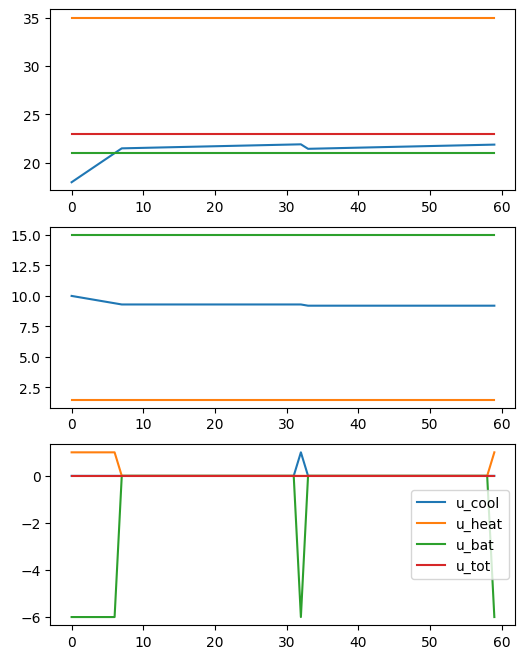

In [ ]:
fig, ax = plt.subplots(3, figsize=(6,8))
ax[0].plot(prob.var_dict['y'].value, label='y')
ax[0].plot(prob.param_dict['d'].value, label='d')
ax[0].plot(prob.param_dict['y_min'].value, label='ymin')
ax[0].plot(prob.param_dict['y_max'].value, label='ymax')

ax[1].plot(prob.var_dict['stored'].value, label='stored')
ax[1].plot(prob.param_dict['bat_min'].value, label='batmin')
ax[1].plot(prob.param_dict['bat_max'].value, label='batmax')

# ax[2].plot(prob.var_dict['u_hvac'].value, label='u_hvac')
ax[2].plot(prob.var_dict['u_cool'].value, label='u_cool')
ax[2].plot(prob.var_dict['u_heat'].value, label='u_heat')
ax[2].plot(prob.var_dict['u_bat'].value, label='u_bat')
ax[2].plot(prob.var_dict['u_tot'].value, label='u_tot')
ax[2].legend()

In [2]:
nsteps_eff = 240
nsteps = nsteps_eff
RC = 400
alpha = 0.08
step_mins = 1

In [16]:
u_cool = cp.Variable((nsteps_eff,1), name='u_cool')
u_cool_sp = cp.Variable((nsteps_eff,1), name='u_cool_sp')
u_bat = cp.Variable((nsteps_eff,1), name='u_bat')
u_tot = cp.Variable((nsteps_eff,1), name='u_tot')
y = cp.Variable((nsteps_eff,1), name='y')
stored = cp.Variable((nsteps_eff,1), name='stored')

y0 = cp.Parameter((1), name='y0')
ymax = cp.Parameter((nsteps_eff,1), name='y_max')
ymin = cp.Parameter((nsteps_eff,1), name='y_min')
d = cp.Parameter((nsteps_eff,1), name='d')
stored0 = cp.Parameter((1), name='stored0')
batmin = cp.Parameter((nsteps_eff,1), name='bat_min')
batmax = cp.Parameter((nsteps_eff,1), name='bat_max')
cost = cp.Parameter((nsteps_eff,1), name='cost')
power_ref = cp.Parameter((nsteps_eff,1), name='power_ref')

# objective = cp.Minimize(1.0*cost.T@u_tot+1.0*cp.norm(y-ymax)+1.0*np.ones(nsteps_eff-1)@cp.power(cp.diff(u_cool),2))
objective = cp.Minimize(
                        # 1.0*cost.T@u_tot
                        +1.0*np.ones(nsteps_eff)@cp.pos(y-ymax)
                        +1.0*np.ones(nsteps_eff)@cp.neg(y-ymin)
                        +2.0*np.ones(nsteps_eff-1)@cp.power(cp.diff(u_cool),2)
                        # +1.0*np.ones(nsteps_eff)@u_cool
                        +1.0*cp.norm(u_cool))
# objective = cp.Minimize(1.0*cost.T@u_tot+1.0*cp.norm(y-ymax)
#                         +1.0*cp.norm(y-ymin)
#                         +3.0*np.ones(nsteps_eff-1)@cp.power(cp.diff(u_cool),2)
#                         +1.0*np.ones(nsteps_eff)@u_cool)

constraints = [ u_cool_sp >= np.ones((nsteps_eff,1))*18,
                u_cool_sp <= np.ones((nsteps_eff,1))*28,
                y[0] == y0,
                # u_cool >= 0,
                # y[1:] <= ymax[1:],
                u_tot == u_cool + u_bat,
                u_bat <= 9.6, u_bat >= -u_cool,
                stored[0] == stored0,
                stored >= batmin, stored <= batmax,
                u_tot <= power_ref,

                # u_cool >= cp.neg(1/alpha * ((u_cool_sp-y) + 1/(RC)*y - 1/(RC)*d))
                # u_cool >= cp.neg(1/alpha * (cp.minimum(u_cool_sp-y,0) + 1/(RC)*y - 1/(RC)*d))
                u_cool == -1/alpha * ((u_cool_sp+0.5-y) + 1/(RC)*y - 1/(RC)*d)
            ]
for i in range(1, nsteps_eff):
    constraints.append(y[i] == (-1/(RC)*y[i-1] + 1/(RC)*d[i-1] + alpha*-u_cool[i-1])*step_mins + y[i-1])
    constraints.append(stored[i] == stored[i-1] + u_bat[i-1] * step_mins / 60)

prob = cp.Problem(objective, constraints)

In [4]:
prob.is_dcp()

True

In [17]:
horizonData = {
    'y0': np.array([27]),
    'y_max': np.ones((nsteps,1))*25,
    'y_min': np.ones((nsteps,1))*20,
    'd': np.concatenate([np.ones((nsteps//2,1))*18, np.ones((nsteps//2,1))*35]),
    'stored0': np.array([1.5]),
    'bat_min': np.ones((nsteps,1))*1.5,
    'bat_max': np.ones((nsteps,1))*15,
    'cost': np.ones((nsteps,1)),
    'power_ref': np.ones((nsteps,1))*7
}

for key, param in prob.param_dict.items():
    param.value = horizonData[key]

prob.solve(verbose=True, solver='gurobi')

(CVXPY) Apr 22 09:04:20 PM: Your problem has 1440 variables, 2640 constraints, and 1442 parameters.


(CVXPY) Apr 22 09:04:20 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 22 09:04:20 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 22 09:04:20 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 22 09:04:20 PM: Compiling problem (target solver=GUROBI).
(CVXPY) Apr 22 09:04:20 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> GUROBI
(CVXPY) Apr 22 09:04:20 PM: Applying reduction Dcp2Cone


                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 22 09:04:20 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 22 09:04:20 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 22 09:04:21 PM: Applying reduction GUROBI
(CVXPY) Apr 22 09:04:21 PM: Finished problem compilation (took 7.415e-01 seconds).
(CVXPY) Apr 22 09:04:21 PM: (Subsequent compilations of this problem, using the same arguments, should take less time.)
(CVXPY) Apr 22 09:04:21 PM: Invoking solver GUROBI  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
Set parameter OutputFlag to value 1
Set parameter QCPDual to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD Ryzen Threadripper PRO 5995WX 64-Cores, instruction set [SSE2|AVX|AVX2]
Thread count: 64 physical cores, 128 logical processors, using up to 32 threads

Non-default parameters:
QCPDual  1

Optimize a model with 4558 rows, 3118 columns and 8391 nonzeros (Min)
Model fingerprint: 0x82771a84
Model has 720 linear objective coefficients
Model has 240 quadratic constraints
Coefficient statistics:
  Matrix range     [2e-02, 1e+01]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e-02, 3e+01]

Presolve removed 2645 rows an

(CVXPY) Apr 22 09:04:21 PM: Problem status: optimal
(CVXPY) Apr 22 09:04:21 PM: Optimal value: 1.831e+01
(CVXPY) Apr 22 09:04:21 PM: Compilation took 7.415e-01 seconds
(CVXPY) Apr 22 09:04:21 PM: Solver (including time spent in interface) took 8.574e-02 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


18.31494854487701

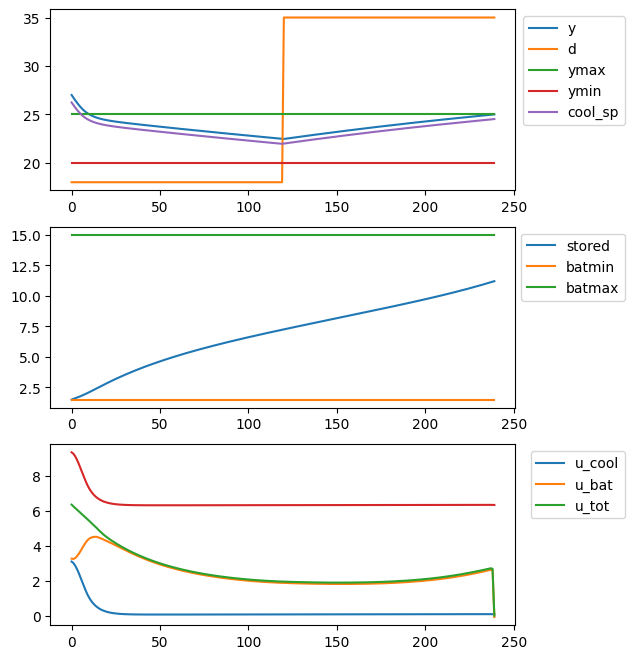

In [18]:
fig, ax = plt.subplots(3, figsize=(6,8))
ax[0].plot(prob.var_dict['y'].value, label='y')
ax[0].plot(prob.param_dict['d'].value, label='d')
ax[0].plot(prob.param_dict['y_max'].value, label='ymax')
ax[0].plot(prob.param_dict['y_min'].value, label='ymin')
ax[0].plot(prob.var_dict['u_cool_sp'].value, label='cool_sp')
ax[0].legend(loc='upper right', bbox_to_anchor=(1.25,1.0))

ax[1].plot(prob.var_dict['stored'].value, label='stored')
ax[1].plot(prob.param_dict['bat_min'].value, label='batmin')
ax[1].plot(prob.param_dict['bat_max'].value, label='batmax')
ax[1].legend(loc='upper right', bbox_to_anchor=(1.25,1.0))

# ax[2].plot(prob.var_dict['u_hvac'].value, label='u_hvac')
ax[2].plot(prob.var_dict['u_cool'].value, label='u_cool')
ax[2].plot(prob.var_dict['u_bat'].value, label='u_bat')
ax[2].plot(prob.var_dict['u_tot'].value, label='u_tot')
ax[2].plot(-np.minimum(1/alpha * ((u_cool_sp.value-y.value) + 1/(RC)*y.value - 1/(RC)*d.value),0))
# ax[2].plot(1/alpha * (np.minimum(u_cool_sp.value-y.value,0) + 1/(RC)*y.value - 1/(RC)*d.value))
ax[2].legend(loc='upper right', bbox_to_anchor=(1.25,1.0))

In [19]:
nsteps_eff = 240
nsteps = nsteps_eff
RC = 400
alpha = 0.08
step_mins = 1

In [43]:
u_cool = cp.Variable((nsteps_eff,1), name='u_cool')
u_cool_sp = cp.Variable((nsteps_eff,1), name='u_cool_sp')
y = cp.Variable((nsteps_eff,1), name='y')

y0 = cp.Parameter((1), name='y0')
ymax = cp.Parameter((nsteps_eff,1), name='y_max')
ymin = cp.Parameter((nsteps_eff,1), name='y_min')
d = cp.Parameter((nsteps_eff,1), name='d')
cost = cp.Parameter((nsteps_eff,1), name='cost')
power_ref = cp.Parameter((nsteps_eff,1), name='power_ref')

objective = cp.Minimize(
                        +1.0*np.ones(nsteps_eff)@cp.pos(y-ymax)
                        # +1.0*np.ones(nsteps_eff)@cp.neg(y-ymin)
                        +2.0*np.ones(nsteps_eff-1)@cp.power(cp.diff(u_cool),2)
                        +1.0*cp.norm(u_cool))

constraints = [ u_cool_sp >= np.ones((nsteps_eff,1))*18,
                u_cool_sp <= np.ones((nsteps_eff,1))*28,
                y[0] == y0,
                u_cool <= power_ref,

                # u_cool >= cp.neg(1/alpha * ((u_cool_sp-y) + 1/(RC)*y - 1/(RC)*d))
                # u_cool >= cp.neg(1/alpha * (cp.minimum(u_cool_sp-y,0) + 1/(RC)*y - 1/(RC)*d))
                u_cool == -1/alpha * ((u_cool_sp+0.5-y) + 1/(RC)*y - 1/(RC)*d)
            ]
for i in range(1, nsteps_eff):
    constraints.append(y[i] == (-1/(RC)*y[i-1] + 1/(RC)*d[i-1] + alpha*-u_cool[i-1])*step_mins + y[i-1])
    # constraints.append(stored[i] == stored[i-1] + u_bat[i-1] * step_mins / 60)

prob = cp.Problem(objective, constraints)

In [44]:
horizonData = {
    'y0': np.array([27]),
    'y_max': np.ones((nsteps,1))*25,
    'y_min': np.ones((nsteps,1))*20,
    'd': np.concatenate([np.ones((nsteps//2,1))*18, np.ones((nsteps//2,1))*35]),
    'cost': np.ones((nsteps,1)),
    'power_ref': np.concatenate([np.zeros((10,1)), np.ones((nsteps//2-10,1))*0.5, np.ones((nsteps//2,1))*1])
}

for key, param in prob.param_dict.items():
    param.value = horizonData[key]

prob.solve(verbose=True, solver='gurobi')

(CVXPY) Apr 22 10:57:22 PM: Your problem has 720 variables, 1200 constraints, and 721 parameters.
(CVXPY) Apr 22 10:57:22 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 22 10:57:22 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 22 10:57:22 PM: Your problem is compiled with the CPP canonicalization backend.


(CVXPY) Apr 22 10:57:22 PM: Compiling problem (target solver=GUROBI).
(CVXPY) Apr 22 10:57:22 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> GUROBI
(CVXPY) Apr 22 10:57:22 PM: Applying reduction Dcp2Cone


                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 22 10:57:22 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 22 10:57:22 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 22 10:57:22 PM: Applying reduction GUROBI
(CVXPY) Apr 22 10:57:22 PM: Finished problem compilation (took 4.789e-01 seconds).
(CVXPY) Apr 22 10:57:22 PM: (Subsequent compilations of this problem, using the same arguments, should take less time.)
(CVXPY) Apr 22 10:57:22 PM: Invoking solver GUROBI  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
Set parameter OutputFlag to value 1
Set parameter QCPDual to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD Ryzen Threadripper PRO 5995WX 64-Cores, instruction set [SSE2|AVX|AVX2]
Thread count: 64 physical cores, 128 logical processors, using up to 32 threads

Non-default parameters:
QCPDual  1

Optimize a model with 2638 rows, 2158 columns and 5033 nonzeros (Min)
Model fingerprint: 0xc9db1765
Model has 480 linear objective coefficients
Model has 240 quadratic constraints
Coefficient statistics:
  Matrix range     [8e-02, 1e+01]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e-02, 3e+01]

Presolve removed 1445 rows an

(CVXPY) Apr 22 10:57:22 PM: Problem status: optimal
(CVXPY) Apr 22 10:57:22 PM: Optimal value: 4.981e+01
(CVXPY) Apr 22 10:57:22 PM: Compilation took 4.789e-01 seconds
(CVXPY) Apr 22 10:57:22 PM: Solver (including time spent in interface) took 5.594e-02 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


49.812129585231574

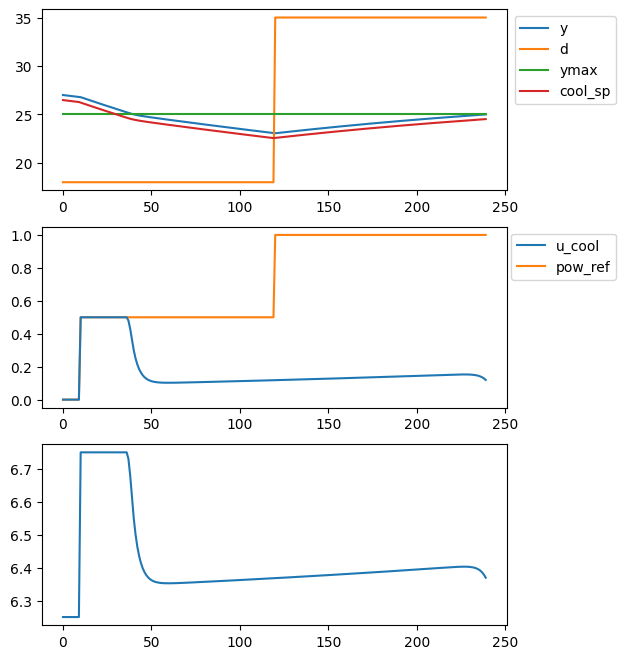

In [45]:
fig, ax = plt.subplots(3, figsize=(6,8))
ax[0].plot(prob.var_dict['y'].value, label='y')
ax[0].plot(prob.param_dict['d'].value, label='d')
ax[0].plot(prob.param_dict['y_max'].value, label='ymax')
# ax[0].plot(prob.param_dict['y_min'].value, label='ymin')
ax[0].plot(prob.var_dict['u_cool_sp'].value, label='cool_sp')
ax[0].legend(loc='upper right', bbox_to_anchor=(1.25,1.0))

ax[1].plot(prob.var_dict['u_cool'].value, label='u_cool')
ax[1].plot(prob.param_dict['power_ref'].value, label='pow_ref', zorder=-1)
ax[1].legend(loc='upper right', bbox_to_anchor=(1.25,1.0))

ax[2].plot(-np.minimum(1/alpha * ((u_cool_sp.value-y.value) + 1/(RC)*y.value - 1/(RC)*d.value),0))
# ax[2].plot(1/alpha * (np.minimum(u_cool_sp.value-y.value,0) + 1/(RC)*y.value - 1/(RC)*d.value))

In [3]:
nsteps_eff = 240
nsteps = nsteps_eff
RC = 400
alpha = 0.08
step_mins = 1

In [4]:
u_cool = cp.Variable((nsteps_eff,1), name='u_cool')
u_cool_sp = cp.Variable((nsteps_eff,1), name='u_cool_sp')
y = cp.Variable((nsteps_eff,1), name='y')

y0 = cp.Parameter((1), name='y0')
ymax = cp.Parameter((nsteps_eff,1), name='y_max')
ymin = cp.Parameter((nsteps_eff,1), name='y_min')
d = cp.Parameter((nsteps_eff,1), name='d')
cost = cp.Parameter((nsteps_eff,1), name='cost')
power_ref = cp.Parameter((nsteps_eff,1), name='power_ref')

objective = cp.Minimize(
                        +1.0*np.ones(nsteps_eff)@cp.pos(y-ymax)
                        +2.0*np.ones(nsteps_eff-1)@cp.power(cp.diff(u_cool),2)
                        +1.0*cp.norm(u_cool))

constraints = [
                y[0] == y0,
                u_cool <= power_ref,

            ]
for i in range(1, nsteps_eff):
    constraints.append(y[i] == (-1/(RC)*y[i-1] + 1/(RC)*d[i-1] + alpha*-u_cool[i-1])*step_mins + y[i-1])

prob = cp.Problem(objective, constraints)

In [11]:
horizonData = {
    'y0': np.array([25]),
    'y_max': np.ones((nsteps,1))*25,
    'y_min': np.ones((nsteps,1))*20,
    # 'd': np.concatenate([np.ones((nsteps//2,1))*18, np.ones((nsteps//2,1))*35]),
    'd': np.ones((nsteps,1))*35,
    'cost': np.ones((nsteps,1)),
    'power_ref': np.concatenate([np.ones((10,1)), np.zeros((20,1)), np.ones((nsteps//2-30,1))*0.5, np.ones((nsteps//2,1))*1])
}

for key, param in prob.param_dict.items():
    param.value = horizonData[key]

prob.solve(verbose=True, solver='gurobi')

(CVXPY) Apr 29 04:36:52 PM: Your problem has 480 variables, 480 constraints, and 721 parameters.
(CVXPY) Apr 29 04:36:52 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 29 04:36:52 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 29 04:36:52 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 29 04:36:52 PM: Using cached ASA map, for faster compilation (bypassing reduction chain).
(CVXPY) Apr 29 04:36:52 PM: Finished problem compilation (took 2.973e-03 seconds).
(CVXPY) Apr 29 04:36:52 PM: Invoking solver GUROBI  to obtain a solution.


                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
Set parameter OutputFlag to value 1
Set parameter QCPDual to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD Ryzen Threadripper PRO 5995WX 64-Cores, instruction set [SSE2|AVX|AVX2]
Thread count: 64 physical cores, 128 logical processors, using up to 32 threads

Non-default parameters:
QCPDual  1

Opti

(CVXPY) Apr 29 04:36:52 PM: Problem status: optimal
(CVXPY) Apr 29 04:36:52 PM: Optimal value: 6.434e+00
(CVXPY) Apr 29 04:36:52 PM: Compilation took 2.973e-03 seconds
(CVXPY) Apr 29 04:36:52 PM: Solver (including time spent in interface) took 1.727e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


6.433939821742705

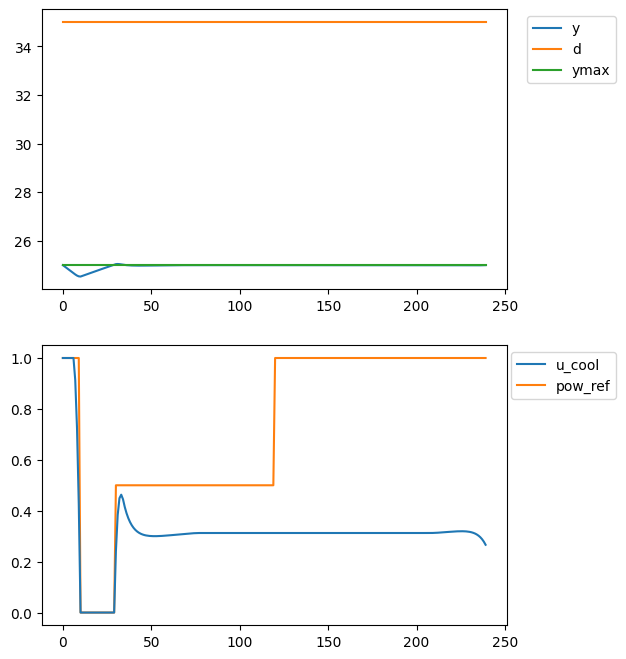

In [12]:
fig, ax = plt.subplots(2, figsize=(6,8))
ax[0].plot(prob.var_dict['y'].value, label='y')
ax[0].plot(prob.param_dict['d'].value, label='d')
ax[0].plot(prob.param_dict['y_max'].value, label='ymax')
ax[0].legend(loc='upper right', bbox_to_anchor=(1.25,1.0))

ax[1].plot(prob.var_dict['u_cool'].value, label='u_cool')
ax[1].plot(prob.param_dict['power_ref'].value, label='pow_ref', zorder=-1)
ax[1].legend(loc='upper right', bbox_to_anchor=(1.25,1.0))